In [ ]:
import numpy as np
from matplotlib import pyplot as plt
# import modred as mr
import matplotlib.pylab as pylab
# import scipy.io as sio
from matplotlib.ticker import FuncFormatter

params={
    'axes.labelsize'  : '24' ,
    'axes.linewidth' : '1.2' ,
    'axes.labelweight': 'bold' ,
#    'font.weight':  'bold' , 
#    'axes.labelcolor':    'red',
# x axis
    'xtick.direction' : 'in' ,
    'xtick.major.size' : '7' ,
    'xtick.major.width' : '1.25' ,
    'xtick.minor.size' : '4.43' ,
    'xtick.minor.width' : '1.25' ,
    'xtick.minor.visible' : 'True' ,
    'xtick.top' : 'True' ,
    'xtick.labelsize' : '24' ,
    'xtick.major.pad' : '10' ,

 #y axis
    'ytick.direction' : 'in' ,
    'ytick.major.size' : '7' ,
    'ytick.major.width' : '1.25' ,
    'ytick.minor.size' : '4.43' ,
    'ytick.minor.width' : '1.25' ,
    'ytick.minor.visible' : 'True' ,
    'ytick.right' : 'True' ,
    'ytick.labelsize' : '24' ,
    'ytick.major.pad' : '10' ,

    'lines.linewidth' : '3.3' ,
    'contour.linewidth' : '0.4',
#legend
    'legend.fontsize' : '22' ,
    'legend.frameon' : 'False',
    'figure.figsize'    : '8, 8',

#Figure layout
#    'figure.autolayout' : 'True' ,
    'figure.subplot.left':   '0.13 ', # the left side of the subplots of the figure
    'figure.subplot.right':  '0.95',   # the right side of the subplots of the figure
    'figure.subplot.bottom': '0.13',   # the bottom of the subplots of the figure
    'figure.subplot.top':    '0.95',   # the top of the subplots of the figure

##font size
#    'font.size' : '50',

# Use LaTeX for math formatting
    'text.usetex' : 'True',
    'text.latex.preamble' : r'\usepackage{amsmath}',
    'text.latex.preamble' : r'\usepackage{bm}'
}
pylab.rcParams.update(params)

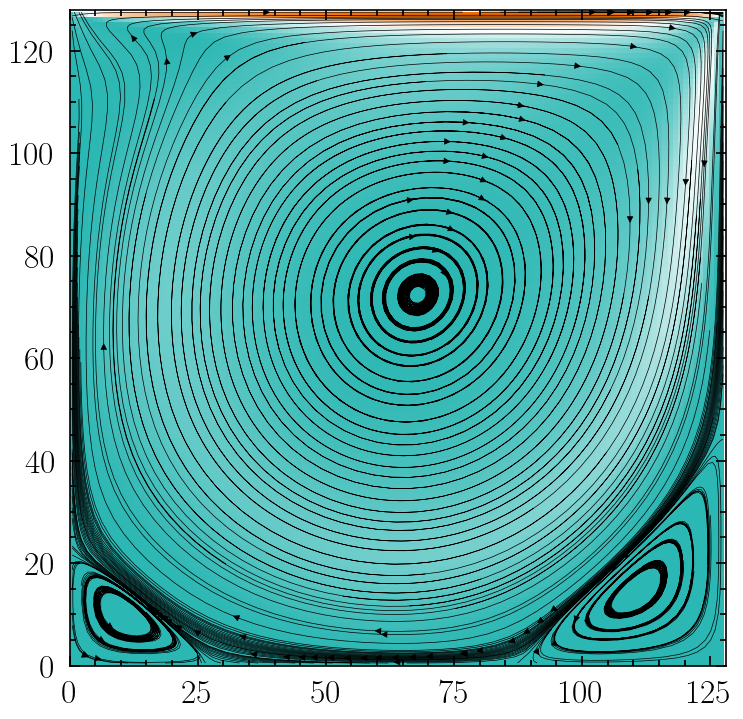

In [10]:
dir = '33re1000/'
nx = 128
ny = 128
nz = 2
nxy = nx*ny
# nsteps = 30

count = 0

iistep = 100000
finameu  = dir +'ux'  + str(iistep) + '.dat'
finamev  = dir +'uy'  + str(iistep) + '.dat'
finamew  = dir +'uz'  + str(iistep) + '.dat'
fnamerho = dir +'rho' + str(iistep) + '.dat'

# read ux
f = open(finameu, 'rb')
recl = np.fromfile(f, dtype='int32', count=1)
f.seek(4)
field = np.fromfile(f, dtype='float64')
# print(field.shape)
data_u =  field.reshape(nx, ny, nz, order= 'F')
# read uy
f = open(finamev, 'rb')
recl = np.fromfile(f, dtype='int32', count=1)
f.seek(4)
field = np.fromfile(f, dtype='float64')
# print(field.shape)
data_v =  field.reshape(nx, ny, nz, order= 'F')
# read uz
f = open(finamew, 'rb')
recl = np.fromfile(f, dtype='int32', count=1)
f.seek(4)
field = np.fromfile(f, dtype='float64')
# print(field.shape)
data_w =  field.reshape(nx, ny, nz, order= 'F')
from matplotlib.colors import LinearSegmentedColormap
sustech = LinearSegmentedColormap.from_list(
    "green_purple", ['#2BB7B3', '#FFFFFF', '#ED6C00']
)

data_plt_u = data_u[:,:,0]
data_plt_v = data_v[:,:,0]
datauv = data_plt_u**2 + data_plt_v**2

uw = 0.1
# Grid Mesh
Y, X = np.mgrid[1:128:128j, 1:128:128j]
Y = Y - 0.5; X = X - 0.5

plt.imshow(datauv, origin='lower', cmap = sustech)
plt.streamplot(X, Y, data_plt_v, data_plt_u, density = 1.2, linewidth = 0.5, color='black', broken_streamlines=False)
# plt.quiver(X[::5,::5], Y[::5,::5], data_u.T[::5,::5]/uw, data_v.T[::5,::5]/uw, scale = 10)
# plt.xticks([0, 360, 720],['0', '0.5', '1.0'] )
# plt.yticks([0, 360, 720],['0', '0.5', '1.0'] )
plt.xlim(0, nx)
plt.ylim(0, nx)
plt.savefig('BBRR33_1000streamline.pdf')
plt.show()

# exit()

-0.022819644872579658


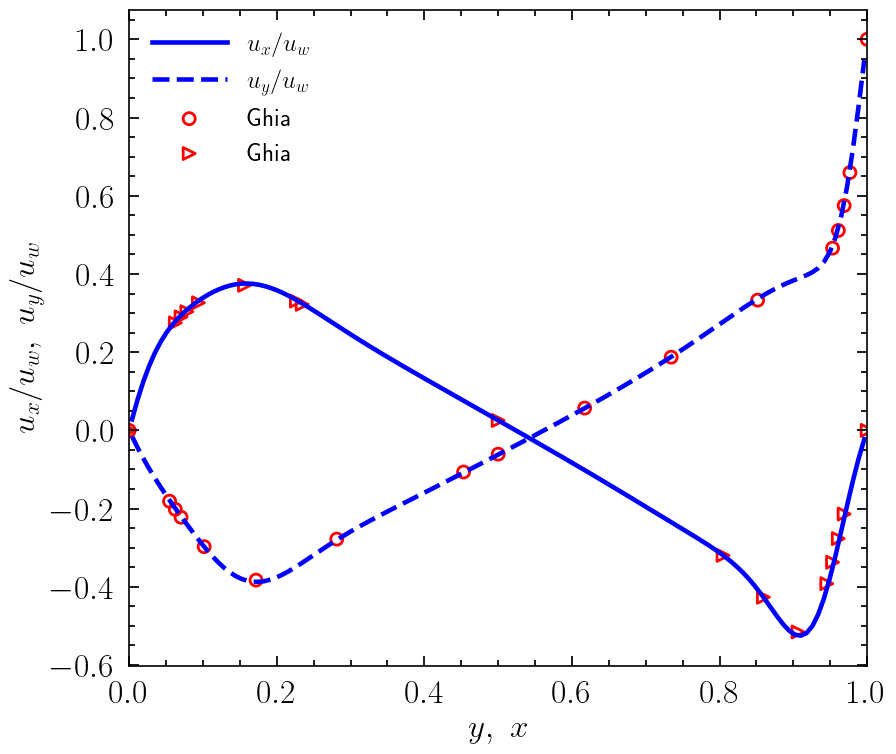

In [94]:
dataref = np.loadtxt('dataref/RE1000.dat')

xx = np.linspace(0.5, nx-0.5, nx)
midl = int(nx/2 - 1); midr = int(nx/2)
print(0.5*(data_plt_u[midl, ny-1] + data_plt_u[midr, ny-1])/uw)
plt.plot(xx[:]/nx, 0.5*(data_plt_u[midl,:] + data_plt_u[midr,:])/uw, c='blue', label = r'$u_x/u_w$')
plt.plot(xx[:]/nx, 0.5*(data_plt_v[:, midl] + data_plt_v[:, midr])/uw, c='blue', ls = '--', label = r'$u_y/u_w$')
plt.scatter(dataref[:,0], dataref[:,1], marker='o', s=75, c='none' , edgecolors= 'red', linewidths= 2.0, label='Ghia')
plt.scatter(dataref[:,2], dataref[:,3], marker='>', s=75, c='none' , edgecolors= 'red', linewidths= 2.0,  label='Ghia')
plt.xlabel(r'$y,\ x$')
plt.ylabel(r'$u_x/u_w,\ u_y/u_w$')
plt.xlim(0, 1)
# plt.ylim(-0.6, 1)
plt.legend(handlelength = 3.0)
plt.show()

9.540979117872439e-17


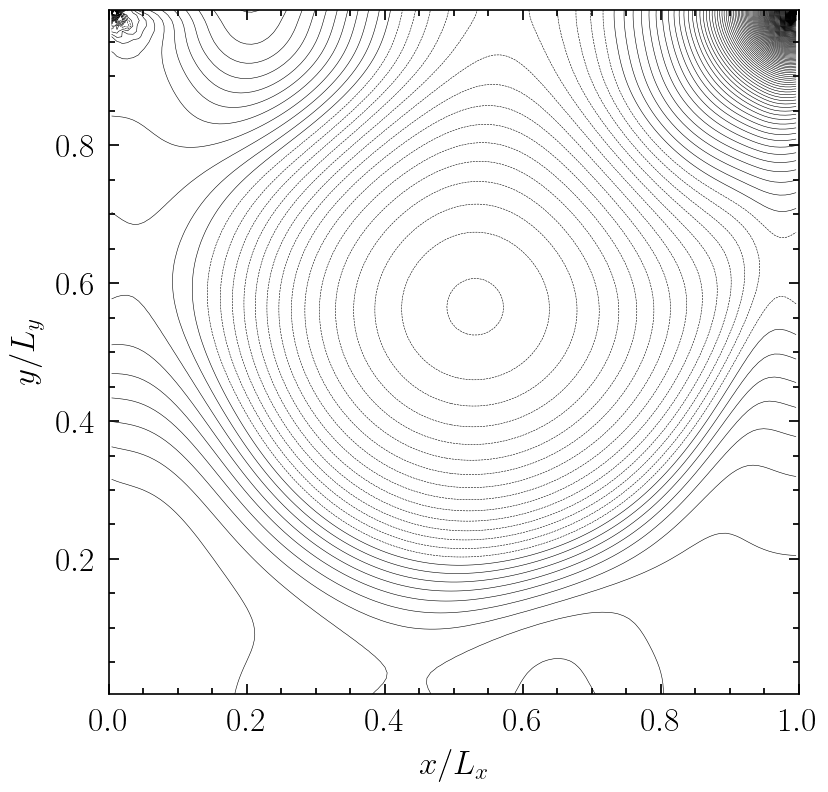

In [13]:
fnamerho = dir+'rho' + str(iistep) + '.dat'

# read ux
f = open(fnamerho, 'rb')
recl = np.fromfile(f, dtype='int32', count=1)
f.seek(4)
field = np.fromfile(f, dtype='float64')
# print(field.shape)
data_rho =  field.reshape(nx, ny, nz, order= 'F')
data_rho_plt =  data_rho[:,:,0] - np.mean(data_rho[:,:,0])

#feature_x = np.linspace(0.5, 192.5, 193) 
feature_x = np.linspace(0.5/128, 127.5/128, 128) 
feature_y =  np.linspace(0.5/128, 127.5/128, 128) 
[XXC, YYC] = np.meshgrid(feature_x, feature_y)
# print(XXC[0,1])
# print(YYC[0,1])
# print(XXC.shape)

# from matplotlib import rcParams
# rcParams['figure.figsize'] = 9, 3
fig,ax = plt.subplots()

delta_lev = 0.005
mean_lev=np.mean(data_rho_plt)
print(mean_lev)
data_rho_plt=data_rho_plt/3./uw**2.
start_lev = np.min(data_rho_plt) ; end_lev = np.max(data_rho_plt)
levels = np.arange(start_lev, end_lev, delta_lev)
length_lev = int((end_lev-start_lev)/delta_lev)

# Generate a color mapping of the levels we've specified
import matplotlib.cm as cm # matplotlib's color map library
# cpf = ax.contourf(XXC, YYC, data_rho_plt.T, len(levels), cmap=cm.Reds)

# Set all level lines to black
# line_colors = ['black' for l in cpf.levels]

# Make plot and customize axes
cp = ax.contour(XXC, YYC, data_rho_plt, levels=levels, colors='black')
# ax.clabel(cp, cp.levels[0:length_lev-40:3], fontsize=16, colors='black', fmt='%1.2f')
line_colors = ['black' for l in cp.levels]

ax.axes.set_aspect('equal')
# ax.set_xlim(0,193)
# ax.set_ylim(128,193)
ax.set_xlim(0,1)
# ax.set_ylim(128/193,1)
plt.xlabel(r'$x/L_x$', labelpad=8)
plt.ylabel(r'$y/L_y$', labelpad=8)
plt.tight_layout(pad=1.0, w_pad=0.5, h_pad=0.5)  # 自动调整布局
plt.savefig('BBRR33_1000pressure.pdf')

plt.show()


In [23]:
# import Ngl

# #  Open a workstation.
# wks_type = "png"
# wks = Ngl.open_wks(wks_type, "0000streamline", None)
# #----------- Begin first plot -----------------------------------------
# res = Ngl.Resources()

# plot = Ngl.streamline(wks, data_u.T[::7,::7], data_v.T[::7,::7], res) 
# Ngl.draw(plot)
# # Ngl.end()

-0.022819644872579658


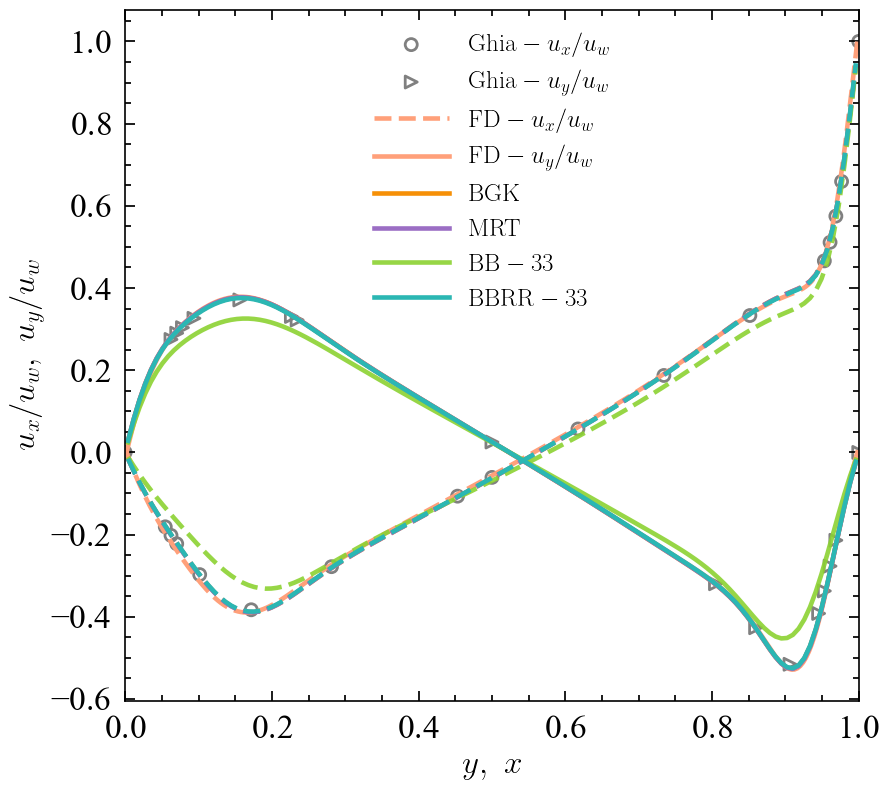

In [50]:
dataref = np.loadtxt('dataref/RE1000.dat')
plt.scatter(dataref[:,0], dataref[:,1], marker='o', s=75, c='none' , edgecolors= 'grey', linewidths= 2.0, label=r'$\mathrm{Ghia}-u_x/u_w$')
plt.scatter(dataref[:,2], dataref[:,3], marker='>', s=75, c='none' , edgecolors= 'grey', linewidths= 2.0,  label=r'$\mathrm{Ghia}-u_y/u_w$')

nxFD = 257
nyFD = 257
istep = 250000
midlFD = int((1+nxFD)/2); midrFD = int((1+nyFD)/2)
fnameuFD   = f"u{istep:07d}.q"
fnamevFD   = f"v{istep:07d}.q"
xxFD = np.linspace(0.5, nxFD-0.5, nxFD)
# read ux
fFD = open(fnameuFD, 'rb')
reclFD = np.fromfile(fFD, dtype='int32', count=1)
fFD.seek(4)
fieldFD = np.fromfile(fFD, dtype='float64')
# print(field.shape)
data_uFD =  fieldFD.reshape(nxFD, nyFD, order= 'F')
# read uy
fFD = open(fnamevFD, 'rb')
reclFD = np.fromfile(fFD, dtype='int32', count=1)
fFD.seek(4)
fieldFD = np.fromfile(fFD, dtype='float64')
# print(field.shape)
data_vFD =  fieldFD.reshape(nxFD, nyFD, order= 'F')
plt.plot(xxFD[:]/nxFD, data_uFD[midlFD,:], c='#FFA07A',ls = '--',label = r'$\mathrm{FD}-u_x/u_w$')
plt.plot(xxFD[:]/nxFD, data_vFD[:, midlFD], c='#FFA07A', label = r'$\mathrm{FD}-u_y/u_w$')

nxRR = 128
nyRR = 128
nzRR=2
xxRR = np.linspace(0.5, nxRR-0.5, nxRR)
midlRR = int(nxRR/2 - 1); midrRR = int(nxRR/2)
uw = 0.1
print(0.5*(data_plt_u[midlRR, nyRR-1] + data_plt_u[midrRR, nyRR-1])/uw)


finameuBB33  = 'ux'  + str(200000) + '.dat'
finamevBB33  = 'uy'  + str(200000) + '.dat'
# read ux
fBB33= open(finameuBB33, 'rb')
reclBB33 = np.fromfile(fBB33, dtype='int32', count=1)
fBB33.seek(4)
fieldBB33 = np.fromfile(fBB33, dtype='float64')
# print(field.shape)
data_uBB33 =  fieldBB33.reshape(nxRR, nyRR, nzRR, order= 'F')
# read uy
fBB33 = open(finamevBB33, 'rb')
reclBB33 = np.fromfile(fBB33, dtype='int32', count=1)
fBB33.seek(4)
fieldBB33 = np.fromfile(fBB33, dtype='float64')
data_vBB33 =  fieldBB33.reshape(nxRR, nyRR, nzRR, order= 'F')

# print(field.shape)
data_plt_uBB = data_uBB33[:,:,0]
data_plt_vBB = data_vBB33[:,:,0]
data_vBB33 =  fieldBB33.reshape(nxRR, nyRR, nzRR, order= 'F')


finameuBGK  = 'BGKux'  + str(95000) + '.dat'
finamevBGK  = 'BGKuy'  + str(95000) + '.dat'
# read ux
fBGK= open(finameuBGK, 'rb')
reclBGK = np.fromfile(fBGK, dtype='int32', count=1)
fBGK.seek(4)
fieldBGK = np.fromfile(fBGK, dtype='float64')
# print(field.shape)
data_uBGK =  fieldBGK.reshape(nxRR, nyRR, nzRR, order= 'F')
# read uy
fBGK = open(finamevBGK, 'rb')
reclBGK = np.fromfile(fBGK, dtype='int32', count=1)
fBGK.seek(4)
fieldBGK = np.fromfile(fBGK, dtype='float64')
data_vBGK =  fieldBGK.reshape(nxRR, nyRR, nzRR, order= 'F')

# print(field.shape)
data_plt_uBGK = data_uBGK[:,:,0]
data_plt_vBGK = data_vBGK[:,:,0]
data_vBGK =  fieldBGK.reshape(nxRR, nyRR, nzRR, order= 'F')
plt.plot(xxRR[:]/nxRR, 0.5*(data_plt_uBGK[midlRR,:] + data_plt_uBGK[midrRR,:])/uw, c='#F69007', label = r'$\mathrm{BGK}$')
plt.plot(xxRR[:]/nxRR, 0.5*(data_plt_vBGK[:, midlRR] + data_plt_vBGK[:, midrRR])/uw, c='#F69007',ls = '--',)

finameuMRT  = 'MRTux'  + str(165000) + '.dat'
finamevMRT  = 'MRTuy'  + str(165000) + '.dat'
# read ux
fMRT= open(finameuMRT, 'rb')
reclMRT = np.fromfile(fMRT, dtype='int32', count=1)
fMRT.seek(4)
fieldMRT = np.fromfile(fMRT, dtype='float64')
# print(field.shape)
data_uMRT =  fieldMRT.reshape(nxRR, nyRR, nzRR, order= 'F')
# read uy
fMRT = open(finamevMRT, 'rb')
reclMRT = np.fromfile(fMRT, dtype='int32', count=1)
fMRT.seek(4)
fieldMRT = np.fromfile(fMRT, dtype='float64')
data_vMRT =  fieldMRT.reshape(nxRR, nyRR, nzRR, order= 'F')

# print(field.shape)
data_plt_uMRT = data_uMRT[:,:,0]
data_plt_vMRT = data_vMRT[:,:,0]
data_vMRT =  fieldMRT.reshape(nxRR, nyRR, nzRR, order= 'F')
plt.plot(xxRR[:]/nxRR, 0.5*(data_plt_uMRT[midlRR,:] + data_plt_uMRT[midrRR,:])/uw, c='#9B6EC4', label = r'$\mathrm{MRT}$')
plt.plot(xxRR[:]/nxRR, 0.5*(data_plt_vMRT[:, midlRR] + data_plt_vMRT[:, midrRR])/uw, c='#9B6EC4',ls = '--',)

plt.plot(xxRR[:]/nxRR, 0.5*(data_plt_uBB[midlRR,:] + data_plt_uBB[midrRR,:])/uw, c='#8cd232',alpha=0.9, label = r'$\mathrm{BB-33}$')
plt.plot(xxRR[:]/nxRR, 0.5*(data_plt_vBB[:, midlRR] + data_plt_vBB[:, midrRR])/uw, c='#8cd232',alpha=0.9,ls = '--',)

plt.plot(xxRR[:]/nxRR, 0.5*(data_plt_u[midlRR,:] + data_plt_u[midrRR,:])/uw, c='#2BB7B3', label = r'$\mathrm{BBRR-33}$')
plt.plot(xxRR[:]/nxRR, 0.5*(data_plt_v[:, midlRR] + data_plt_v[:, midrRR])/uw, c='#2BB7B3', ls = '--')

plt.xlabel(r'$y,\ x$')
plt.ylabel(r'$u_x/u_w,\ u_y/u_w$')
plt.xlim(0, 1)
# plt.ylim(-0.6, 1)
plt.legend(handlelength = 3.0)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_usetex(False)
    label.set_fontfamily('Times New Roman')

plt.tight_layout()
plt.savefig('u.pdf')
plt.show()